In [66]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from PIL import Image
import zipfile

from sklearn.model_selection import train_test_split

In [67]:
zip_path = r"C:Downloads\archive (1).zip"

In [68]:
images = []

zip_file = zipfile.ZipFile(zip_path, "r")

for file in zip_file.namelist():

    if file.lower().endswith((".jpg", ".jpeg", ".png")):

        try:

            img = Image.open(
                zip_file.open(file)
            ).convert("RGB")

            img = img.resize((28, 28))

            images.append(np.array(img))

        except:
            pass

        # Take only 5000 images
        if len(images) == 5000:
            break


zip_file.close()


In [69]:
x = np.array(images)

print("Images:", x.shape)


Images: (5000, 28, 28, 3)


In [70]:
x = x.astype("float32") / 255.0


In [71]:
x_train, x_test = train_test_split(
    x,
    test_size=0.2,
    random_state=42
)

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)


Training images: (4000, 28, 28, 3)
Testing images: (1000, 28, 28, 3)


In [72]:
encoder = Sequential([

    layers.Input(shape=(28, 28, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D((2, 2))
])

In [73]:
decoder = Sequential([

    layers.Conv2DTranspose(
        64,
        (3, 3),
        strides=2,
        activation="relu",
        padding="same"
    ),

    layers.Conv2DTranspose(
        32,
        (3, 3),
        strides=2,
        activation="relu",
        padding="same"
    ),

    layers.Conv2D(
        3,
        (3, 3),
        activation="sigmoid",
        padding="same"
    )
])


In [74]:
autoencoder = models.Sequential([
    encoder,
    decoder
])

In [75]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)


In [76]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_test, x_test)
)



Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 105s 626ms/step - loss: 0.6582 - val_loss: 0.5834
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 501ms/step - loss: 0.5533 - val_loss: 0.5340
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 508ms/step - loss: 0.5287 - val_loss: 0.5230


In [78]:
reconstructed = autoencoder.predict(
    x_test[:5]
)


print("Minimum:", reconstructed.min())
print("Maximum:", reconstructed.max())
print("Mean:", reconstructed.mean())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
Minimum: 0.009838032
Maximum: 0.96446794
Mean: 0.41485408


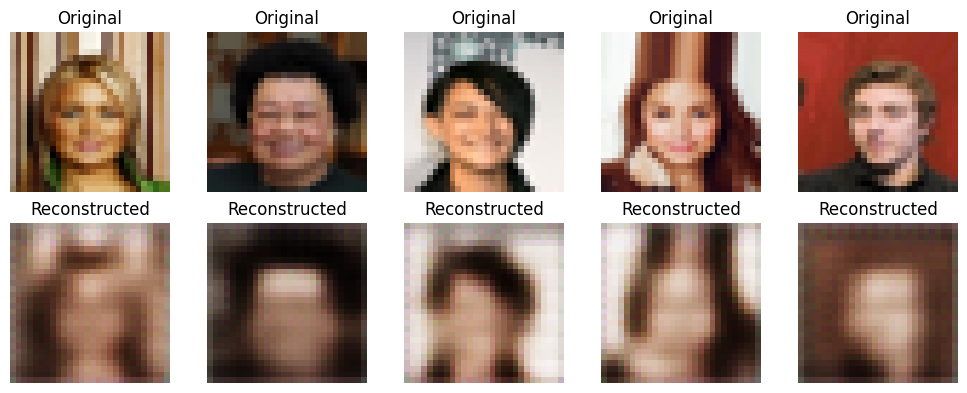

In [79]:
plt.figure(figsize=(10, 4))

for i in range(5):

    # Original
    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[i])

    plt.axis("off")

    plt.title("Original")


    # Reconstructed
    plt.subplot(2, 5, i + 6)

    plt.imshow(reconstructed[i])

    plt.axis("off")

    plt.title("Reconstructed")


plt.tight_layout()
plt.show()